In [44]:
import ultralytics
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

In [2]:
from ultralytics import YOLO
model = YOLO("./runs/detect/train4/weights/best.pt")

In [3]:
res = model('./craters_task/craters/test/images/010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg')

/home/kirilman/miniconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:138: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


image 1/1 /media/kirilman/Z4/URFU/Компьютерное зрение/Deep-Learning-Foundation-Course-main/data/Итоговые практики/data/Обнаруж.объектов итог/craters_task/craters/test/images/010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg: 640x640 31 0s, 84.5ms
Speed: 6.9ms preprocess, 84.5ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)


In [4]:
res[0].show()

In [41]:
def rle_encode_tensor(mask_tensor):
    """
    Encode a PyTorch binary mask tensor into Kaggle-style RLE string.

    Args:
        mask_tensor: torch.Tensor of shape (H, W) or (1, H, W)
                     dtype: bool, int, or float (will be thresholded at 0.5 if float)

    Returns:
        str: RLE string (e.g., "1 3 10 5 ...") or empty string if no foreground
    """
    # Убираем лишние измерения
    if mask_tensor.ndim == 3:
        if mask_tensor.shape[0] == 1:
            mask_tensor = mask_tensor.squeeze(0)
        else:
            raise ValueError("Expected single-channel mask, got shape: {}".format(mask_tensor.shape))

    # Переводим на CPU и в numpy
    mask = mask_tensor.detach().cpu().numpy()

    # Бинаризуем, если нужно
    if mask.dtype == np.float32 or mask.dtype == np.float64:
        mask = mask > 0.5
    else:
        mask = mask.astype(bool)

    # Проверка на пустую маску
    if mask.sum() == 0:
        return ""

    # RLE в column-major порядке (Kaggle стандарт)
    pixels = mask.T.flatten()  # <-- ВАЖНО: .T для column-major
    pixels = np.concatenate([[0], pixels, [0]])  # паддинг
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]

    return ' '.join(str(x) for x in runs)


def rle_decode(rle_string: str, shape: tuple) -> np.ndarray:
    """
    Decode a Kaggle-style RLE string into a binary mask.

    Args:
        rle_string (str): RLE string like "10 5 20 8" (start1 len1 start2 len2 ...)
        shape (tuple): (height, width) of the output mask

    Returns:
        np.ndarray: Binary mask of shape (height, width), dtype=np.uint8
    """
    if not rle_string or rle_string == "-1" or rle_string.strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    rle = np.array(rle_string.split(), dtype=int)
    starts = rle[0::2] - 1  # Convert from 1-indexed to 0-indexed
    lengths = rle[1::2]

    flat_mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, length in zip(starts, lengths):
        flat_mask[start : start + length] = 1

    mask = flat_mask.reshape(shape)
    return mask


In [45]:
path2image = Path('./craters_task/craters/test/images/')
img = cv2.imread('./craters_task/craters/test/images/010_png.rf.fcf5e274562ee69a325f9d7a0b30767f.jpg')
w,h,_ = img.shape


0: 640x640 12 0s, 53.1ms
Speed: 21.9ms preprocess, 53.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 8 0s, 53.3ms
Speed: 1.2ms preprocess, 53.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 0s, 51.4ms
Speed: 1.1ms preprocess, 51.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 9 0s, 55.3ms
Speed: 1.1ms preprocess, 55.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 13 0s, 52.0ms
Speed: 1.2ms preprocess, 52.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 0s, 53.8ms
Speed: 1.1ms preprocess, 53.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 0, 47.8ms
Speed: 1.4ms preprocess, 47.8ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 0, 48.5ms
Speed: 1.2ms preprocess, 48.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 17 0s, 49.0

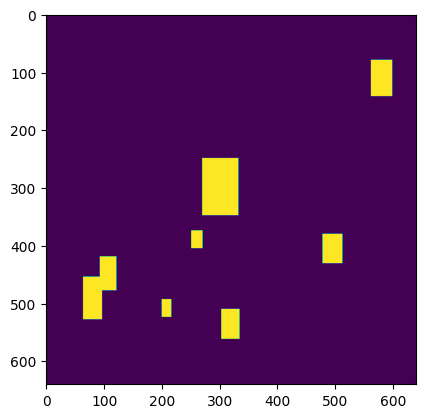

In [51]:
masks = []

for f_img in path2image.glob("*.jpg"):
    ans = np.zeros((w,h))
    img = cv2.imread(f_img)
    w, h, _ = img.shape
    pred = model(img)[0]
    boxes = pred.boxes.data
    for box in boxes:
        x1,y1, x2, y2 = box[:4].detach().cpu().numpy().astype(np.int32)
        ans[y1:y2, x1:x2] = 1
    masks.append((f_img.name,img,ans))
plt.imshow(ans)

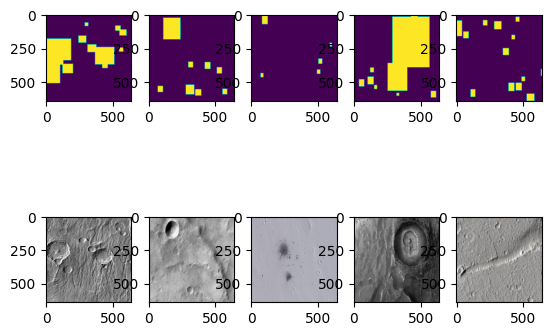

In [62]:
fig, ax = plt.subplots(2,5)
for i in range(5):
    name, img, mask = masks[i]
    ax[0][i].imshow(mask)
    ax[1][i].imshow(img)